# BERT from Scratch

BERT is a transformer encoder that is trained twice. The first pass, **pretraining**, sees only raw
sequences and no labels: positions are hidden at random and the model is asked to fill them back in
from the surrounding context. The second pass, **fine-tuning**, attaches a small classification head
and trains the whole thing on labelled data. The claim the method makes is that the representation
built in the first pass is a better starting point than random numbers, and that this matters most
when labels are scarce.

The sibling notebook `transformer_from_scratch.ipynb` builds a plain encoder on the same DNA
sequences and trains it directly on the labels, in one stage. This notebook is the two-stage
contrast. Everything else - the data, the split, the encoder block, the size of the model - is kept
deliberately modest so that the only thing being varied is *where the weights came from* when
fine-tuning starts.

The experiment at the centre of the notebook is a sweep: fine-tune from pretrained weights and from
random weights, at 50, 100, 200, 500 and 2552 labelled sequences, with an identical training budget,
and plot both accuracy curves on the same axes.

In [1]:
# BLAS oversubscription makes these small matrix products slower, so pin the thread count
# before numpy is imported.
import os

for _v in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS']:
    os.environ[_v] = '1'

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange, green = '#2a78d6', '#eb6834', '#1baf7a'

notebook_start = time.time()
np.set_printoptions(suppress=True)
print('ready')

ready


## The data

`fetch_ucirepo(id=69)` downloads the UCI splice-junction gene sequences: 3190 stretches of DNA, each
exactly 60 bases long, held in columns `Base1` to `Base60`. Every sequence is centred on a candidate
junction sitting between positions 30 and 31, and the label says what kind of boundary it is:

- `EI` - an exon/intron boundary, a **donor** site, 767 sequences
- `IE` - an intron/exon boundary, an **acceptor** site, 768 sequences
- `N`  - neither, 1655 sequences

The raw cells carry leading whitespace, so every entry is stripped. Besides the four bases `A`,
`C`, `G`, `T` the file contains 60 cells holding the ambiguity codes `N`, `D`, `R` and `S`, which
stand for "one of several bases". They are too rare to model separately and are folded into a single
`UNK` symbol. That leaves a base vocabulary of five.

The majority class is `N` at 1655 of 3190, so a classifier that always answers `N` scores
**0.519**. Every accuracy in this notebook is quoted against that number.

In [2]:
splice = fetch_ucirepo(id=69)

raw = np.array([[str(v).strip() for v in row] for row in splice.data.features.values])
labels = np.array([str(s).strip() for s in splice.data.targets.values.ravel()])

BASES = ['A', 'C', 'G', 'T', 'UNK']
base_id = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

X_bases = np.array([[base_id.get(ch, 4) for ch in row] for row in raw], dtype=np.int64)
CLASSES = ['EI', 'IE', 'N']
y_all = np.array([CLASSES.index(s) for s in labels], dtype=np.int64)

n_amb = int((X_bases == 4).sum())
baseline = np.bincount(y_all).max() / len(y_all)

print('sequences:', X_bases.shape)
print('class counts:', dict(zip(CLASSES, np.bincount(y_all))))
print('ambiguity codes folded into UNK:', n_amb)
print('majority-class baseline: %.4f' % baseline)

sequences: (3190, 60)
class counts: {'EI': 767, 'IE': 768, 'N': 1655}
ambiguity codes folded into UNK: 60
majority-class baseline: 0.5188


The cell below draws the class balance and the base composition at each of the 60 positions. The
composition plot is the reason this dataset is learnable at all: away from the junction the four
bases sit near their background frequencies, but in a narrow window around positions 30 and 31 the
proportions swing sharply. That window is the splice-site motif, and it is the signal both the
masked language model and the classifier have to find.

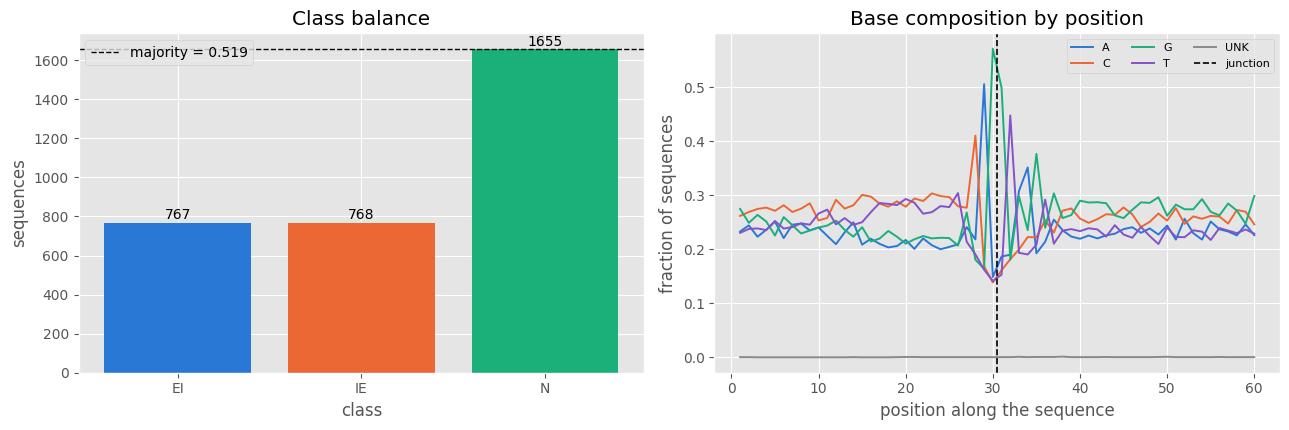

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

counts = np.bincount(y_all)
ax[0].bar(CLASSES, counts, color=[blue, orange, green])
ax[0].axhline(counts.max(), color='k', ls='--', lw=1, label='majority = %.3f' % baseline)
for i, c in enumerate(counts):
    ax[0].text(i, c + 20, str(c), ha='center')
ax[0].set_title('Class balance')
ax[0].set_xlabel('class')
ax[0].set_ylabel('sequences')
ax[0].legend()

comp = np.zeros((5, 60))
for b in range(5):
    comp[b] = (X_bases == b).mean(0)
pos = np.arange(1, 61)
for b, (nm, col) in enumerate(zip(BASES, [blue, orange, green, '#8452c9', '#8a8a8a'])):
    ax[1].plot(pos, comp[b], color=col, lw=1.4, label=nm)
ax[1].axvline(30.5, color='k', ls='--', lw=1.2, label='junction')
ax[1].set_title('Base composition by position')
ax[1].set_xlabel('position along the sequence')
ax[1].set_ylabel('fraction of sequences')
ax[1].legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

## Tokens, `[CLS]`, and the vocabulary

The model works on integer token ids, not letters. The vocabulary holds the five base symbols plus
three special tokens:

| id | token | role |
|----|-------|------|
| 0-3 | `A` `C` `G` `T` | the four bases |
| 4 | `UNK` | the folded ambiguity codes |
| 5 | `[MASK]` | stands in for a hidden position during pretraining |
| 6 | `[CLS]` | prepended to every sequence; its final hidden state is the sequence representation |
| 7 | `[PAD]` | reserved; unused here because every sequence is exactly 60 bases |

So the vocabulary size is $V = 8$ and every input is $L = 61$ tokens long: `[CLS]` followed by the
60 bases.

**Why a dedicated `[CLS]` token rather than averaging the 61 hidden states.** A mean over positions
weights every base equally and is permutation-invariant, so it throws away exactly the thing the
encoder just computed - which positions mattered and how they relate. The label here depends on a
short motif in a specific place, and averaging dilutes it across 60 positions. `[CLS]` avoids that.
It carries no base identity of its own, so its representation is built purely out of what it
attends to; the attention weights in its row are free to concentrate on the junction and ignore the
background. It is a learned, content-dependent pooling operator rather than a fixed one.

The split is 80/20 with seed 0: 2552 training sequences and 638 test sequences. Pretraining uses the
training sequences with `y_train` never touched.

In [4]:
MASK_ID, CLS_ID, PAD_ID = 5, 6, 7
VOCAB = BASES + ['[MASK]', '[CLS]', '[PAD]']
V = len(VOCAB)
L = 61

ids_all = np.concatenate([np.full((len(X_bases), 1), CLS_ID, dtype=np.int64), X_bases], axis=1)

rng = np.random.default_rng(0)
order = rng.permutation(len(ids_all))
n_train = int(0.8 * len(ids_all))
train_idx, test_idx = order[:n_train], order[n_train:]

ids_train, ids_test = ids_all[train_idx], ids_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print('vocabulary:', VOCAB, ' V =', V, ' L =', L)
print('train:', ids_train.shape, ' test:', ids_test.shape)
print('first training sequence, first 12 tokens:', ids_train[0, :12])
print('   as symbols:', [VOCAB[t] for t in ids_train[0, :12]])

vocabulary: ['A', 'C', 'G', 'T', 'UNK', '[MASK]', '[CLS]', '[PAD]']  V = 8  L = 61
train: (2552, 61)  test: (638, 61)
first training sequence, first 12 tokens: [6 0 2 1 0 3 0 0 3 2 3 2]
   as symbols: ['[CLS]', 'A', 'G', 'C', 'A', 'T', 'A', 'A', 'T', 'G', 'T', 'G']


## Why the masking is necessary

A left-to-right language model maximises the probability of each token given everything before it:

$$J_{LM} = -\sum_{t} \log P(x_t \mid x_{<t})$$

That objective only makes sense if the model is prevented from looking ahead, which is what the
causal mask in a decoder does: before the softmax, every attention score at position $t$ that points
to a position $> t$ is set to $-\infty$, so those weights come out at zero. Position $t$ sees a
strictly smaller context than position $t+1$.

An encoder has no such mask. Every position attends to every other position in both directions, so
the hidden state at position $t$ is a function of the whole sequence - including $x_t$ itself. Under
that architecture $J_{LM}$ becomes trivial: the model can read the answer off its own input and
drive the loss to zero by learning the identity map, having learned nothing about the language.
Bidirectional context and next-token prediction are incompatible.

The masked language modelling objective repairs this by deleting the answer from the input:

$$J_{MLM} = -\sum_{i \in M} \log P(x_i \mid \mathbf{x}_{\setminus M})$$

where $M$ is the set of chosen positions and $\mathbf{x}_{\setminus M}$ is the sequence with those
positions corrupted. The conditioning set now runs in **both** directions - positions before $i$ and
after $i$ both contribute - while $x_i$ itself has been removed, so the task is not degenerate. The
price is that only the $|M|$ chosen positions produce a gradient signal per sequence, roughly 15% of
them, which is why MLM pretraining needs more passes over the data than a left-to-right model does.

The same trade explains what BERT cannot do. Generating text left to right requires
$P(x_t \mid x_{<t})$ for every $t$ in one pass, and an encoder that has only ever been asked to fill
in gaps in an otherwise complete sequence has never been trained to produce that.

## The encoder block

Each block is attention followed by a position-wise feed-forward network, with a residual connection
and a layer normalisation around each. Attention is scaled dot-product attention:

$$\text{Attention}(Q,K,V)=\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

with $Q = HW^Q$, $K = HW^K$, $V = HW^V$ computed from the block input $H \in \mathbb{R}^{L \times d}$.
The product $QK^\top$ is $L \times L$; entry $(i,j)$ scores how much position $i$ should read from
position $j$, and the softmax runs along $j$ so each row sums to one. The $\sqrt{d_k}$ divisor keeps
the scores from growing with the head width - a dot product of two $d_k$-dimensional vectors with
unit-variance entries has variance $d_k$, and without the correction the softmax saturates and the
gradient through it vanishes.

Multi-head attention runs $h$ of these in parallel on $d_k = d/h$ slices and concatenates:

$$\text{MultiHead}(H) = \left[\text{head}_1, \dots, \text{head}_h\right]W^O,
\qquad \text{head}_i = \text{Attention}(HW_i^Q, HW_i^K, HW_i^V)$$

One softmax produces one distribution per position, so a single head can only average over one
pattern at a time; several heads let different subspaces attend to different things at once.

Layer normalisation standardises each position's vector across its own $d$ features:

$$\text{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta,
\qquad \mu = \frac{1}{d}\sum_k x_k, \quad \sigma^2 = \frac{1}{d}\sum_k (x_k - \mu)^2$$

The full block, in the original post-norm arrangement:

$$H' = \text{LN}_1\!\left(H + \text{MultiHead}(H)\right), \qquad
H'' = \text{LN}_2\!\left(H' + W_2\,\text{GELU}(W_1 H' + b_1) + b_2\right)$$

The feed-forward network is applied to each position separately with the same weights, and it is
the only place in the block where a non-linearity acts. GELU is used in the smooth tanh form

$$\text{GELU}(x) = \tfrac{1}{2}x\left(1 + \tanh\!\left[\sqrt{2/\pi}\,(x + 0.044715x^3)\right]\right)$$

**Positional embeddings.** Attention is permutation-equivariant - shuffle the input positions and
the outputs shuffle with them - so position has to be injected. This notebook uses a **learned**
positional embedding: a table $P \in \mathbb{R}^{L \times d}$ added to the token embeddings, one row
per position, trained like any other parameter. Sinusoidal embeddings are the alternative and they
extrapolate to lengths never seen in training; that property is worth nothing here because every
sequence is exactly 61 tokens, and a learned table can specialise freely - in particular it can give
the positions around the junction their own distinct codes.

The embedding sum is layer-normalised before it enters the first block:

$$H^{(0)} = \text{LN}_{\text{emb}}\!\left(E[\mathbf{x}] + P\right)$$

In [5]:
EPS = 1e-5


def softmax(z, axis=-1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


def gelu(x):
    c = np.sqrt(2.0 / np.pi)
    return 0.5 * x * (1.0 + np.tanh(c * (x + 0.044715 * x ** 3)))


def gelu_grad(x):
    c = np.sqrt(2.0 / np.pi)
    t = np.tanh(c * (x + 0.044715 * x ** 3))
    return 0.5 * (1.0 + t) + 0.5 * x * (1.0 - t ** 2) * c * (1.0 + 3 * 0.044715 * x ** 2)


def ln_forward(x, g, b):
    mu = x.mean(-1, keepdims=True)
    xc = x - mu
    inv = 1.0 / np.sqrt((xc ** 2).mean(-1, keepdims=True) + EPS)
    xh = xc * inv
    return g * xh + b, (xh, inv, g)


def ln_backward(dy, cache):
    xh, inv, g = cache
    D = xh.shape[-1]
    axes = tuple(range(dy.ndim - 1))
    dg = (dy * xh).sum(axis=axes)
    db = dy.sum(axis=axes)
    dxh = dy * g
    dx = (inv / D) * (D * dxh - dxh.sum(-1, keepdims=True) - xh * (dxh * xh).sum(-1, keepdims=True))
    return dx, dg, db


def lin_forward(x, W, b):
    return x @ W + b


def lin_backward(dy, x, W):
    din, dout = W.shape
    dW = x.reshape(-1, din).T @ dy.reshape(-1, dout)
    db = dy.reshape(-1, dout).sum(0)
    return dy @ W.T, dW, db


def split_heads(x, H):
    B, L_, d = x.shape
    return x.reshape(B, L_, H, d // H).transpose(0, 2, 1, 3)


def merge_heads(x):
    B, H, L_, dk = x.shape
    return x.transpose(0, 2, 1, 3).reshape(B, L_, H * dk)


print('primitives defined')

primitives defined


The model is deliberately small: $d = 32$, 4 heads of width 8, a feed-forward width of 64, and 2
encoder blocks. Weights are drawn from $\mathcal{N}(0, 0.02^2)$ and all biases start at zero, with
layer-norm gains at one. The cell prints the parameter count broken down by component.

In [6]:
d_model, n_heads, d_ff, n_layers, n_classes = 32, 4, 64, 2, 3


def init_params(seed):
    r = np.random.default_rng(seed)
    s = 0.02
    p = {}
    p['E'] = r.normal(0, s, (V, d_model))
    p['P'] = r.normal(0, s, (L, d_model))
    p['emb_g'] = np.ones(d_model)
    p['emb_b'] = np.zeros(d_model)
    for l in range(n_layers):
        for nm in ['Wq', 'Wk', 'Wv', 'Wo']:
            p['L%d_%s' % (l, nm)] = r.normal(0, s, (d_model, d_model))
            p['L%d_%sb' % (l, nm[1])] = np.zeros(d_model)
        p['L%d_ln1_g' % l] = np.ones(d_model)
        p['L%d_ln1_b' % l] = np.zeros(d_model)
        p['L%d_W1' % l] = r.normal(0, s, (d_model, d_ff))
        p['L%d_b1' % l] = np.zeros(d_ff)
        p['L%d_W2' % l] = r.normal(0, s, (d_ff, d_model))
        p['L%d_b2' % l] = np.zeros(d_model)
        p['L%d_ln2_g' % l] = np.ones(d_model)
        p['L%d_ln2_b' % l] = np.zeros(d_model)
    p['mlm_W1'] = r.normal(0, s, (d_model, d_model))
    p['mlm_b1'] = np.zeros(d_model)
    p['mlm_W2'] = r.normal(0, s, (d_model, V))
    p['mlm_b2'] = np.zeros(V)
    p['cls_W'] = r.normal(0, s, (d_model, n_classes))
    p['cls_b'] = np.zeros(n_classes)
    return p


params0 = init_params(0)


def group_of(k):
    if k in ('E',):
        return 'token embedding'
    if k in ('P',):
        return 'positional embedding'
    if k.startswith('emb_'):
        return 'embedding layer norm'
    if k.startswith('mlm_'):
        return 'MLM head'
    if k.startswith('cls_'):
        return 'classification head'
    if k[3] in 'Wq' and k[4:] in ('q', 'k', 'v', 'o') or k[4:] in ('Wq', 'Wk', 'Wv', 'Wo', 'qb', 'kb', 'vb', 'ob'):
        return 'encoder %s attention' % k[:2]
    if 'ln' in k:
        return 'encoder %s layer norms' % k[:2]
    return 'encoder %s feed-forward' % k[:2]


totals = {}
for k, v_ in params0.items():
    totals[group_of(k)] = totals.get(group_of(k), 0) + v_.size

for k in sorted(totals):
    print('%-28s %6d' % (k, totals[k]))
n_params = sum(totals.values())
n_encoder = n_params - totals['MLM head'] - totals['classification head']
print('-' * 35)
print('%-28s %6d' % ('total', n_params))
print('%-28s %6d' % ('  of which encoder', n_encoder))

MLM head                       1320
classification head              99
embedding layer norm             64
encoder L0 attention           4096
encoder L0 feed-forward        4320
encoder L0 layer norms          128
encoder L1 attention           4096
encoder L1 feed-forward        4320
encoder L1 layer norms          128
positional embedding           1952
token embedding                 256
-----------------------------------
total                         20779
  of which encoder            19360


## Forward pass

`encoder_forward` maps a batch of token id arrays of shape `(B, 61)` to hidden states of shape
`(B, 61, 32)`. There is no mask anywhere in it - the softmax over `scores` runs across all 61
positions, so position $i$ reads from every $j$ including $j > i$. That single absence is what makes
this an encoder rather than a decoder.

Everything needed by the backward pass is stored in the cache as it is computed.

In [7]:
def encoder_forward(p, ids, keep_attn=False):
    B, L_ = ids.shape
    dk = d_model // n_heads
    scale = 1.0 / np.sqrt(dk)
    c = {'ids': ids, 'blocks': [], 'attn': []}

    x = p['E'][ids] + p['P'][None, :L_, :]
    h, c['emb'] = ln_forward(x, p['emb_g'], p['emb_b'])

    for l in range(n_layers):
        bc = {'h_in': h}
        Q = lin_forward(h, p['L%d_Wq' % l], p['L%d_qb' % l])
        K = lin_forward(h, p['L%d_Wk' % l], p['L%d_kb' % l])
        Vv = lin_forward(h, p['L%d_Wv' % l], p['L%d_vb' % l])
        Qh, Kh, Vh = split_heads(Q, n_heads), split_heads(K, n_heads), split_heads(Vv, n_heads)

        scores = (Qh @ Kh.transpose(0, 1, 3, 2)) * scale   # no causal mask: both directions
        A = softmax(scores, -1)
        cm = merge_heads(A @ Vh)
        att = lin_forward(cm, p['L%d_Wo' % l], p['L%d_ob' % l])

        h1, bc['ln1'] = ln_forward(bc['h_in'] + att, p['L%d_ln1_g' % l], p['L%d_ln1_b' % l])
        z1 = lin_forward(h1, p['L%d_W1' % l], p['L%d_b1' % l])
        a1 = gelu(z1)
        z2 = lin_forward(a1, p['L%d_W2' % l], p['L%d_b2' % l])
        h2, bc['ln2'] = ln_forward(h1 + z2, p['L%d_ln2_g' % l], p['L%d_ln2_b' % l])

        bc.update({'Qh': Qh, 'Kh': Kh, 'Vh': Vh, 'A': A, 'cm': cm, 'h1': h1, 'z1': z1, 'a1': a1})
        c['blocks'].append(bc)
        if keep_attn:
            c['attn'].append(A)
        h = h2

    return h, c


_h, _c = encoder_forward(params0, ids_train[:4])
print('hidden states:', _h.shape)
print('attention rows sum to 1:', np.allclose(_c['blocks'][0]['A'].sum(-1), 1.0))

hidden states: (4, 61, 32)
attention rows sum to 1: True


## Backward pass

The gradients follow the forward pass in reverse. Three pieces are worth stating explicitly.

**Softmax.** With $a = \text{softmax}(s)$ along the last axis, the Jacobian-vector product collapses
to

$$\frac{\partial J}{\partial s_j} = a_j\left(\frac{\partial J}{\partial a_j} - \sum_k a_k \frac{\partial J}{\partial a_k}\right)$$

so no $L \times L$ Jacobian is ever built.

**Layer norm.** Because $\mu$ and $\sigma^2$ both depend on every component of $x$, the gradient
does not pass through elementwise. With $\hat{x} = (x-\mu)/\sqrt{\sigma^2+\epsilon}$ and
$\partial J/\partial \hat{x} = \gamma \odot \partial J/\partial y$,

$$\frac{\partial J}{\partial x} = \frac{1}{d\sqrt{\sigma^2+\epsilon}}
\left(d\,\frac{\partial J}{\partial \hat{x}} - \sum_k \frac{\partial J}{\partial \hat{x}_k}
- \hat{x}\sum_k \hat{x}_k \frac{\partial J}{\partial \hat{x}_k}\right)$$

**Residual and embedding.** A residual connection sends the same gradient down both branches, so the
contributions are summed. The token embedding is a gather, and the gradient of a gather is a scatter-
add: a base that occurs many times in the batch accumulates one contribution per occurrence, which
is what `np.add.at` does.

In [8]:
def encoder_backward(dh, p, c):
    dk = d_model // n_heads
    scale = 1.0 / np.sqrt(dk)
    g = {}

    for l in range(n_layers - 1, -1, -1):
        bc = c['blocks'][l]
        dr2, g['L%d_ln2_g' % l], g['L%d_ln2_b' % l] = ln_backward(dh, bc['ln2'])
        dh1 = dr2.copy()
        da1, g['L%d_W2' % l], g['L%d_b2' % l] = lin_backward(dr2, bc['a1'], p['L%d_W2' % l])
        dz1 = da1 * gelu_grad(bc['z1'])
        dx, g['L%d_W1' % l], g['L%d_b1' % l] = lin_backward(dz1, bc['h1'], p['L%d_W1' % l])
        dh1 += dx

        dr1, g['L%d_ln1_g' % l], g['L%d_ln1_b' % l] = ln_backward(dh1, bc['ln1'])
        dh_in = dr1.copy()
        dcm, g['L%d_Wo' % l], g['L%d_ob' % l] = lin_backward(dr1, bc['cm'], p['L%d_Wo' % l])

        dctx = split_heads(dcm, n_heads)
        A = bc['A']
        dA = dctx @ bc['Vh'].transpose(0, 1, 3, 2)
        dVh = A.transpose(0, 1, 3, 2) @ dctx
        ds = A * (dA - (dA * A).sum(-1, keepdims=True)) * scale
        dQh = ds @ bc['Kh']
        dKh = ds.transpose(0, 1, 3, 2) @ bc['Qh']

        hin = bc['h_in']
        for dpart, wn, bn in [(merge_heads(dQh), 'Wq', 'qb'), (merge_heads(dKh), 'Wk', 'kb'),
                              (merge_heads(dVh), 'Wv', 'vb')]:
            dx, g['L%d_%s' % (l, wn)], g['L%d_%s' % (l, bn)] = lin_backward(dpart, hin, p['L%d_%s' % (l, wn)])
            dh_in += dx
        dh = dh_in

    dx, g['emb_g'], g['emb_b'] = ln_backward(dh, c['emb'])
    g['P'] = dx.sum(0)
    dE = np.zeros_like(p['E'])
    np.add.at(dE, c['ids'], dx)
    g['E'] = dE
    return g


print('backward defined')

backward defined


## The two heads

The **MLM head** takes the hidden states at the chosen positions only, pushes them through a small
non-linear projection and then out to the vocabulary:

$$P(x_i \mid \mathbf{x}_{\setminus M}) = \text{softmax}\!\left(W_2\,\text{GELU}(W_1 h_i + b_1) + b_2\right)$$

Gathering the chosen positions first means the head runs on roughly 9 vectors per sequence instead
of 61, and the unselected positions receive gradient only through the encoder, which is exactly what
the objective asks for.

The **classification head** is a single affine map on the `[CLS]` hidden state:

$$P(y \mid \mathbf{x}) = \text{softmax}\!\left(W_{cls}\, h_{[CLS]} + b_{cls}\right)$$

Both use softmax cross-entropy, whose gradient with respect to the logits is the familiar
$\hat{p} - y_{\text{one-hot}}$, divided here by the number of terms because the loss is a mean.

In [9]:
def ce_loss(logits, targets):
    pr = softmax(logits, -1)
    n = len(targets)
    loss = -np.log(np.maximum(pr[np.arange(n), targets], 1e-12)).mean()
    dl = pr.copy()
    dl[np.arange(n), targets] -= 1.0
    return loss, dl / n, pr


def mlm_step(p, ids, rows, cols, targets, want_grad=True):
    h, c = encoder_forward(p, ids)
    hs = h[rows, cols]
    z1 = lin_forward(hs, p['mlm_W1'], p['mlm_b1'])
    a1 = gelu(z1)
    loss, dlogits, pr = ce_loss(lin_forward(a1, p['mlm_W2'], p['mlm_b2']), targets)
    if not want_grad:
        return loss, pr, None
    da1, gW2, gb2 = lin_backward(dlogits, a1, p['mlm_W2'])
    dz1 = da1 * gelu_grad(z1)
    dhs, gW1, gb1 = lin_backward(dz1, hs, p['mlm_W1'])
    dh = np.zeros_like(h)
    np.add.at(dh, (rows, cols), dhs)
    g = encoder_backward(dh, p, c)
    g['mlm_W1'], g['mlm_b1'], g['mlm_W2'], g['mlm_b2'] = gW1, gb1, gW2, gb2
    g['cls_W'] = np.zeros_like(p['cls_W'])
    g['cls_b'] = np.zeros_like(p['cls_b'])
    return loss, pr, g


def cls_step(p, ids, y, want_grad=True):
    h, c = encoder_forward(p, ids)
    hc = h[:, 0, :]
    loss, dlogits, pr = ce_loss(lin_forward(hc, p['cls_W'], p['cls_b']), y)
    if not want_grad:
        return loss, pr, None
    dhc, gW, gb = lin_backward(dlogits, hc, p['cls_W'])
    dh = np.zeros_like(h)
    dh[:, 0, :] = dhc
    g = encoder_backward(dh, p, c)
    g['cls_W'], g['cls_b'] = gW, gb
    for k in ['mlm_W1', 'mlm_b1', 'mlm_W2', 'mlm_b2']:
        g[k] = np.zeros_like(p[k])
    return loss, pr, g


print('heads defined')

heads defined


## Gradient check

Every derivative above was written by hand, so each one is compared against a central finite
difference. For a single scalar weight $w$,

$$\frac{\partial J}{\partial w} \approx \frac{J(w+\varepsilon) - J(w-\varepsilon)}{2\varepsilon}
+ O(\varepsilon^2)$$

with $\varepsilon = 10^{-5}$. The check runs on a small model with $L = 14$ so the two extra forward
passes per weight are cheap, and it covers both objectives. For each weight the coordinate with the
largest analytic gradient is chosen, because a coordinate whose true derivative is near zero has a
relative error dominated by floating-point noise in the difference rather than by anything about the
backward pass.

The weights checked include an attention projection in each block, the token and positional
embeddings, both MLM head matrices, a layer-norm gain, both feed-forward matrices and the
classification head.

In [10]:
_save = (d_model, n_heads, d_ff, n_layers, L)
d_model, n_heads, d_ff, n_layers, L = 16, 4, 32, 2, 14

gp = init_params(3)
gr = np.random.default_rng(11)
for k in gp:
    gp[k] = gp[k] + gr.normal(0, 0.05, gp[k].shape)

g_ids = gr.integers(0, 5, (6, L))
g_ids[:, 0] = CLS_ID
g_rows = np.array([0, 1, 2, 3, 4, 5, 0, 2])
g_cols = np.array([3, 5, 7, 2, 9, 11, 12, 4])
g_tgt = gr.integers(0, 5, 8)
g_y = gr.integers(0, 3, 6)

f_mlm = lambda q: mlm_step(q, g_ids, g_rows, g_cols, g_tgt, False)[0]
f_cls = lambda q: cls_step(q, g_ids, g_y, False)[0]

grad_mlm = mlm_step(gp, g_ids, g_rows, g_cols, g_tgt)[2]
grad_cls = cls_step(gp, g_ids, g_y)[2]

checks = [('L0_Wq', 'MLM'), ('L1_Wk', 'MLM'), ('L0_Wv', 'MLM'), ('L1_Wo', 'MLM'),
          ('E', 'MLM'), ('P', 'MLM'), ('mlm_W1', 'MLM'), ('mlm_W2', 'MLM'), ('mlm_b2', 'MLM'),
          ('L0_ln1_g', 'MLM'), ('L1_W1', 'MLM'), ('L0_W2', 'MLM'),
          ('L1_Wv', 'CLS'), ('E', 'CLS'), ('P', 'CLS'), ('cls_W', 'CLS'), ('L0_Wq', 'CLS')]

eps = 1e-5
worst = 0.0
print('%-9s %-4s %-9s %16s %16s %10s' % ('weight', 'obj', 'index', 'analytic', 'measured', 'rel err'))
for k, which in checks:
    fn = f_mlm if which == 'MLM' else f_cls
    gg = grad_mlm if which == 'MLM' else grad_cls
    idx = np.unravel_index(np.argmax(np.abs(gg[k])), gg[k].shape)
    orig = gp[k][idx]
    gp[k][idx] = orig + eps
    lp = fn(gp)
    gp[k][idx] = orig - eps
    lm = fn(gp)
    gp[k][idx] = orig
    num = (lp - lm) / (2 * eps)
    ana = gg[k][idx]
    rel = abs(num - ana) / max(1e-12, abs(num) + abs(ana))
    worst = max(worst, rel)
    print('%-9s %-4s %-9s %+16.10f %+16.10f %10.2e' % (k, which, str(idx), ana, num, rel))

print()
print('largest relative disagreement: %.3e' % worst)
assert worst < 1e-5
d_model, n_heads, d_ff, n_layers, L = _save
print('gradient check passed')

weight    obj  index             analytic         measured    rel err
L0_Wq     MLM  (6, 12)      -0.0000139701    -0.0000139702   4.91e-07
L1_Wk     MLM  (4, 1)       +0.0000385780    +0.0000385780   1.32e-07
L0_Wv     MLM  (2, 10)      +0.0005999917    +0.0005999917   6.40e-10
L1_Wo     MLM  (9, 13)      +0.0010625444    +0.0010625444   1.19e-08
E         MLM  (3, 13)      -0.0634571961    -0.0634571961   3.77e-10
P         MLM  (5, 0)       +0.0301664834    +0.0301664834   7.92e-10
mlm_W1    MLM  (11, 5)      -0.0275137336    -0.0275137336   1.38e-10
mlm_W2    MLM  (1, 1)       -0.0680075504    -0.0680075504   9.43e-11
mlm_b2    MLM  (4,)         -0.5012830127    -0.5012830127   2.16e-11
L0_ln1_g  MLM  (6,)         -0.0014016383    -0.0014016383   4.60e-09
L1_W1     MLM  (12, 30)     -0.0007592949    -0.0007592949   6.22e-10
L0_W2     MLM  (21, 13)     -0.0010021517    -0.0010021517   7.95e-09
L1_Wv     CLS  (4, 6)       -0.0029232934    -0.0029232935   1.24e-09
E         CLS  (6, 1

## The masking scheme

For each sequence, 15% of the 60 base positions are selected at random - about 9 of them. `[CLS]` is
never selected; it has no base identity to predict. Each selected position is then corrupted by one
of three rules:

- with probability **0.8** it is replaced by `[MASK]`
- with probability **0.1** it is replaced by a base drawn uniformly from the five base symbols
- with probability **0.9 to 1.0**, that is the remaining **0.1**, it is left exactly as it is

The loss is computed at the selected positions only, against the original base, in all three cases.

**Why the split is not simply 100% `[MASK]`.** The `[MASK]` token exists only during pretraining. At
fine-tuning time, and at test time, no input ever contains it. If every position the model were
scored on had been replaced by `[MASK]`, the model would only ever need a good representation at
positions carrying that one token, and it could learn to treat `[MASK]` as a trigger: build a
predictive state there and leave the other positions as pass-through copies of their own input. The
representations that fine-tuning then inherits would be the wrong ones - a train/test mismatch
between the pretraining input distribution and every input the model sees afterwards.

The other two cases remove that shortcut. In the 10% random-replacement case the input token is a
plausible base and is *wrong*, so a model that copies its own input is penalised; it has to consult
the context to notice the substitution. In the 10% unchanged case the input token is a plausible base
and is *right*, so a model that ignores its own input is penalised too. Because the model cannot tell
which of those two cases it is in, it has no choice but to compute a context-aware prediction at
every position it is scored on, and since selection is uniform over positions, that means every
position. The representation that survives into fine-tuning is therefore useful everywhere, not just
where `[MASK]` sits.

In [11]:
def make_mlm_batch(batch, r):
    inp = batch.copy()
    sel = r.random(batch.shape) < 0.15
    sel[:, 0] = False                      # never select [CLS]
    rows, cols = np.nonzero(sel)
    targets = batch[rows, cols]
    u = r.random(len(rows))
    to_mask = u < 0.8
    to_rand = (u >= 0.8) & (u < 0.9)       # the remaining 10% are left unchanged
    inp[rows[to_mask], cols[to_mask]] = MASK_ID
    inp[rows[to_rand], cols[to_rand]] = r.integers(0, 5, int(to_rand.sum()))
    return inp, rows, cols, targets, to_mask, to_rand


_r = np.random.default_rng(4)
_inp, _rows, _cols, _tgt, _m, _rd = make_mlm_batch(ids_train[:256], _r)
print('selected positions per sequence: %.2f of 60 (%.1f%%)' % (len(_rows) / 256, 100 * len(_rows) / (256 * 60)))
print('of the selected: %.1f%% masked, %.1f%% randomised, %.1f%% unchanged'
      % (100 * _m.mean(), 100 * _rd.mean(), 100 * (~_m & ~_rd).mean()))

selected positions per sequence: 9.15 of 60 (15.3%)
of the selected: 78.4% masked, 10.7% randomised, 10.9% unchanged


The next cell shows the rule applied to one concrete sequence. The top row is the original 60 bases,
the middle row marks which positions were selected, and the bottom row is what the model actually
receives - `[MASK]` in most selected slots, a randomly drawn base in a few, and the original base,
untouched, in a few more. Only the pillars marked in the middle row contribute to the loss.

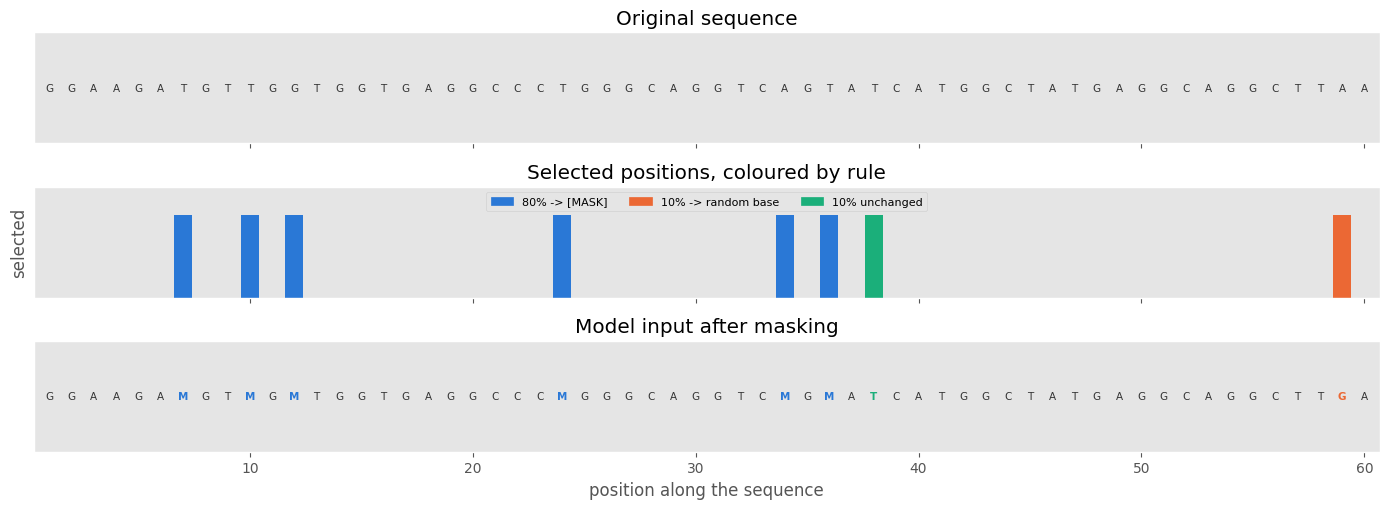

selected positions: [ 7 10 12 24 34 36 38 59]
true bases there  : ['T', 'T', 'G', 'T', 'A', 'T', 'T', 'A']


In [12]:
_r1 = np.random.default_rng(12)
one = ids_train[3:4]
oi, orow, ocol, otgt, om, ord_ = make_mlm_batch(one, _r1)

kind = np.zeros(61, dtype=int)          # 0 untouched, 1 masked, 2 randomised, 3 kept
for j, cpos in enumerate(ocol):
    kind[cpos] = 1 if om[j] else (2 if ord_[j] else 3)

fig, ax = plt.subplots(3, 1, figsize=(14, 5.2), sharex=True)
xs = np.arange(1, 61)
cols_kind = {0: '#c9c9c9', 1: blue, 2: orange, 3: green}

for a in ax:
    a.set_xlim(0.3, 60.7)
    a.grid(False)

for j in range(60):
    ax[0].text(j + 1, 0.5, BASES[one[0, j + 1]], ha='center', va='center', fontsize=7.5, color='#333333')
ax[0].set_ylim(0, 1)
ax[0].set_yticks([])
ax[0].set_title('Original sequence')

ax[1].bar(xs, (kind[1:] > 0).astype(float), color=[cols_kind[k] for k in kind[1:]], width=0.8)
ax[1].set_ylim(0, 1.35)
ax[1].set_yticks([])
ax[1].set_ylabel('selected')
ax[1].set_title('Selected positions, coloured by rule')
handles = [plt.Rectangle((0, 0), 1, 1, color=cols_kind[k]) for k in [1, 2, 3]]
ax[1].legend(handles, ['80% -> [MASK]', '10% -> random base', '10% unchanged'], ncol=3, fontsize=8, loc='upper center')

for j in range(60):
    tok = VOCAB[oi[0, j + 1]]
    txt = 'M' if tok == '[MASK]' else tok
    ax[2].text(j + 1, 0.5, txt, ha='center', va='center', fontsize=7.5,
               color=cols_kind[kind[j + 1]] if kind[j + 1] else '#333333',
               weight='bold' if kind[j + 1] else 'normal')
ax[2].set_ylim(0, 1)
ax[2].set_yticks([])
ax[2].set_title('Model input after masking')
ax[2].set_xlabel('position along the sequence')

plt.tight_layout()
plt.show()

print('selected positions:', ocol)
print('true bases there  :', [BASES[t] for t in otgt])

## Stage 1: pretraining

Pretraining runs on `ids_train` and nothing else. `y_train` is not referenced anywhere in the loop -
the only supervision is the sequence predicting its own hidden positions, which is why the stage is
unsupervised even though it is trained with cross-entropy.

The optimiser is Adam with bias correction:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \qquad
w_t = w_{t-1} - \eta\,\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}$$

with $\beta_1 = 0.9$, $\beta_2 = 0.999$. Pretraining uses $\eta = 10^{-3}$ and batches of 32.

A fresh mask is drawn every time a sequence is visited, so the same sequence poses a different
fill-in-the-blank problem on each epoch and 2552 sequences generate far more than 2552 training
examples.

Two reference lines matter when reading the accuracy. Guessing uniformly among the five base symbols
gives **0.200**. Always answering the single most common base in the corpus gives **0.263**. Anything
above the second line is structure the model has extracted from context.

In [13]:
def adam_init(p):
    return {k: np.zeros_like(v) for k, v in p.items()}, {k: np.zeros_like(v) for k, v in p.items()}


def adam_step(p, g, m, v, t, lr, b1=0.9, b2=0.999, e=1e-8):
    for k in p:
        if k not in g:
            continue
        m[k] = b1 * m[k] + (1 - b1) * g[k]
        v[k] = b2 * v[k] + (1 - b2) * g[k] ** 2
        p[k] -= lr * (m[k] / (1 - b1 ** t)) / (np.sqrt(v[k] / (1 - b2 ** t)) + e)


uniform_chance = 1.0 / 5
majority_base = max(np.bincount(X_bases.ravel(), minlength=5) / X_bases.size)
print('uniform chance %.3f   most common base %.3f' % (uniform_chance, majority_base))

uniform chance 0.200   most common base 0.263


In [14]:
PRE_EPOCHS, PRE_BATCH, PRE_LR = 12, 32, 1e-3

pre_params = init_params(0)
pm, pv = adam_init(pre_params)
pre_rng = np.random.default_rng(7)

mlm_loss_hist, mlm_acc_hist = [], []
t_pre = time.time()
step = 0

for ep in range(PRE_EPOCHS):
    perm = pre_rng.permutation(len(ids_train))
    tot, cor, seen = 0.0, 0, 0
    for s in range(0, len(perm), PRE_BATCH):
        batch = ids_train[perm[s:s + PRE_BATCH]]                 # sequences only, labels untouched
        inp, rows, cols, tgt, _, _ = make_mlm_batch(batch, pre_rng)
        loss, pr, g = mlm_step(pre_params, inp, rows, cols, tgt)
        step += 1
        adam_step(pre_params, g, pm, pv, step, PRE_LR)
        tot += loss * len(tgt)
        cor += int((pr.argmax(1) == tgt).sum())
        seen += len(tgt)
    mlm_loss_hist.append(tot / seen)
    mlm_acc_hist.append(cor / seen)
    print('epoch %2d/%d   MLM loss %.4f   masked-token accuracy %.4f   [%.0fs]'
          % (ep + 1, PRE_EPOCHS, tot / seen, cor / seen, time.time() - t_pre), flush=True)

pretrain_seconds = time.time() - t_pre
print('pretraining finished in %.0fs over %d gradient steps' % (pretrain_seconds, step))

epoch  1/12   MLM loss 1.6234   masked-token accuracy 0.2644   [10s]


epoch  2/12   MLM loss 1.3897   masked-token accuracy 0.2685   [27s]


epoch  3/12   MLM loss 1.3684   masked-token accuracy 0.3420   [45s]


epoch  4/12   MLM loss 1.3094   masked-token accuracy 0.3786   [66s]


epoch  5/12   MLM loss 1.3007   masked-token accuracy 0.3876   [87s]


...

epoch  9/12   MLM loss 1.2805   masked-token accuracy 0.4020   [169s]


epoch 10/12   MLM loss 1.2893   masked-token accuracy 0.3953   [192s]


epoch 11/12   MLM loss 1.2824   masked-token accuracy 0.3994   [213s]


epoch 12/12   MLM loss 1.2806   masked-token accuracy 0.4019   [234s]


pretraining finished in 234s over 960 gradient steps


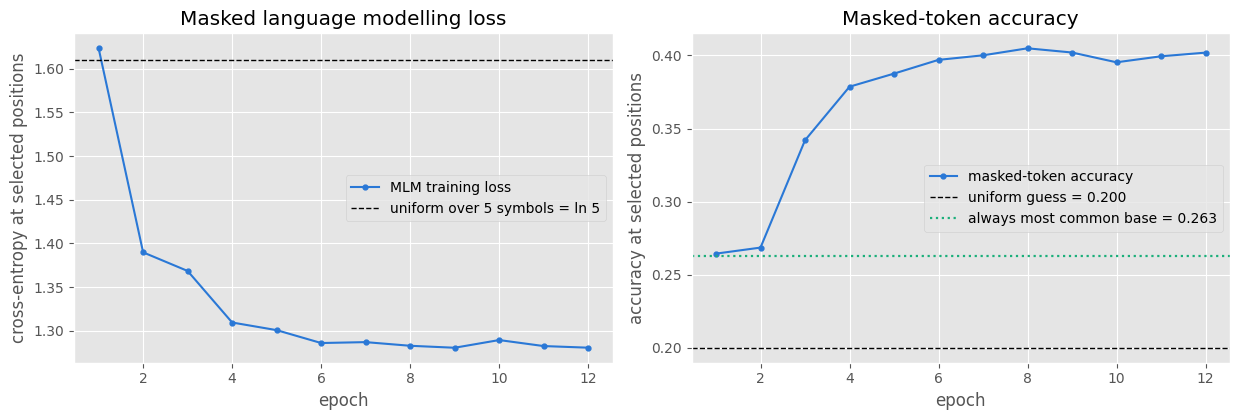

final masked-token accuracy 0.4019  vs uniform 0.200  vs most common base 0.263


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
eps_x = np.arange(1, PRE_EPOCHS + 1)

ax[0].plot(eps_x, mlm_loss_hist, color=blue, marker='o', ms=3.5, label='MLM training loss')
ax[0].axhline(np.log(5), color='k', ls='--', lw=1, label='uniform over 5 symbols = ln 5')
ax[0].set_title('Masked language modelling loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('cross-entropy at selected positions')
ax[0].legend()

ax[1].plot(eps_x, mlm_acc_hist, color=blue, marker='o', ms=3.5, label='masked-token accuracy')
ax[1].axhline(uniform_chance, color='k', ls='--', lw=1, label='uniform guess = %.3f' % uniform_chance)
ax[1].axhline(majority_base, color=green, ls=':', lw=1.6, label='always most common base = %.3f' % majority_base)
ax[1].set_title('Masked-token accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy at selected positions')
ax[1].legend()

plt.tight_layout()
plt.show()

print('final masked-token accuracy %.4f  vs uniform %.3f  vs most common base %.3f'
      % (mlm_acc_hist[-1], uniform_chance, majority_base))

## Stage 2: fine-tuning

The classification objective is cross-entropy on the `[CLS]` state,

$$J_{cls} = -\frac{1}{N}\sum_{n=1}^{N} \log P\!\left(y^{(n)} \mid \mathbf{x}^{(n)}\right),
\qquad P(y \mid \mathbf{x}) = \text{softmax}\!\left(W_{cls}\, h_{[CLS]} + b_{cls}\right)$$

and **all** weights are updated, not just the head. The two-stage schedule is

$$\theta^{\ast} = \arg\min_\theta J_{MLM}(\theta) \quad \text{at } \eta_{pre} = 10^{-3},
\qquad \theta^{\dagger} = \arg\min_{\theta,\,\phi} J_{cls}(\theta, \phi)
\ \text{ from } \theta = \theta^{\ast}, \ \eta_{fine} = 5 \times 10^{-4}$$

where $\phi$ is the freshly initialised classification head. The fine-tuning rate is lower because
$\theta^{\ast}$ is already a good configuration and large steps would destroy it before the head has
learned to read it - the head starts random, so the first gradients that arrive at the encoder are
noise.

**The comparison.** `finetune` is called with two different starting points and is otherwise
identical: same subset of labelled sequences, same batch size, same number of gradient steps, same
learning rate, same random stream, same fresh head. The only difference is whether the encoder
weights are $\theta^{\ast}$ or a fresh draw from $\mathcal{N}(0, 0.02^2)$. Each configuration is run
with 3 seeds, which vary both which sequences land in the labelled subset and the head
initialisation, and the results are reported as a mean with a standard deviation - at 50 labels the
spread between seeds is large enough that a single run would say nothing.

In [16]:
def evaluate(p, ids_e, y_e):
    correct = 0
    for s in range(0, len(ids_e), 256):
        h, _ = encoder_forward(p, ids_e[s:s + 256])
        logits = lin_forward(h[:, 0, :], p['cls_W'], p['cls_b'])
        correct += int((logits.argmax(1) == y_e[s:s + 256]).sum())
    return correct / len(ids_e)


FINE_LR = 5e-4


def finetune(init, n, seed, steps, eval_every=25):
    r = np.random.default_rng(1000 + seed)
    sub = r.permutation(len(ids_train))[:n]
    xi, yi = ids_train[sub], y_train[sub]

    q = {k: v.copy() for k, v in init.items()}
    fresh = init_params(500 + seed)
    q['cls_W'], q['cls_b'] = fresh['cls_W'].copy(), fresh['cls_b'].copy()
    m, v = adam_init(q)

    B = min(32, n)
    curve_x, curve_loss, curve_acc = [], [], []
    run_loss = 0.0
    for t in range(1, steps + 1):
        j = r.integers(0, n, B)
        loss, pr, g = cls_step(q, xi[j], yi[j])
        adam_step(q, g, m, v, t, FINE_LR)
        run_loss += loss
        if t % eval_every == 0:
            curve_x.append(t)
            curve_loss.append(run_loss / eval_every)
            curve_acc.append(evaluate(q, ids_test, y_test))
            run_loss = 0.0
    return q, evaluate(q, ids_test, y_test), (curve_x, curve_loss, curve_acc)


print('fine-tuning routine ready')

fine-tuning routine ready


In [17]:
SIZES = [50, 100, 200, 500, len(ids_train)]
STEPS = {50: 150, 100: 150, 200: 150, 500: 150, len(ids_train): 400}
SEEDS = [0, 1, 2]

results = {}
curves = {}
final_model = None
t_sweep = time.time()

for n in SIZES:
    for mode in ['pretrained', 'scratch']:
        accs = []
        for sd in SEEDS:
            start = pre_params if mode == 'pretrained' else init_params(500 + sd)
            q, acc, cv = finetune(start, n, sd, STEPS[n])
            accs.append(acc)
            if sd == 0:
                curves[(n, mode)] = cv
            if mode == 'pretrained' and n == SIZES[-1] and sd == 0:
                final_model = q
        results[(n, mode)] = np.array(accs)
        print('n=%5d  %-11s  test accuracy %.4f +- %.4f   %s   [%.0fs]'
              % (n, mode, np.mean(accs), np.std(accs), np.round(accs, 3), time.time() - t_sweep), flush=True)

sweep_seconds = time.time() - t_sweep
print('sweep finished in %.0fs' % sweep_seconds)

n=   50  pretrained   test accuracy 0.6787 +- 0.0549   [0.737 0.694 0.605]   [138s]


n=   50  scratch      test accuracy 0.5366 +- 0.0104   [0.545 0.522 0.542]   [255s]


n=  100  pretrained   test accuracy 0.7503 +- 0.0244   [0.762 0.773 0.716]   [371s]


n=  100  scratch      test accuracy 0.5993 +- 0.0186   [0.599 0.577 0.622]   [459s]


n=  200  pretrained   test accuracy 0.7476 +- 0.0970   [0.803 0.829 0.611]   [544s]


...

n=  500  pretrained   test accuracy 0.7315 +- 0.0827   [0.705 0.843 0.646]   [664s]


n=  500  scratch      test accuracy 0.6808 +- 0.0090   [0.691 0.669 0.682]   [724s]


n= 2552  pretrained   test accuracy 0.9211 +- 0.0247   [0.945 0.931 0.887]   [880s]


n= 2552  scratch      test accuracy 0.8678 +- 0.0292   [0.875 0.829 0.9  ]   [1043s]


sweep finished in 1043s


The headline figure puts both curves on the same axes. The horizontal line is the 0.519 majority
baseline. The claim under test is that the blue curve sits above the orange one and that the gap
closes as labels become plentiful; the shaded bands are one standard deviation over the three seeds.

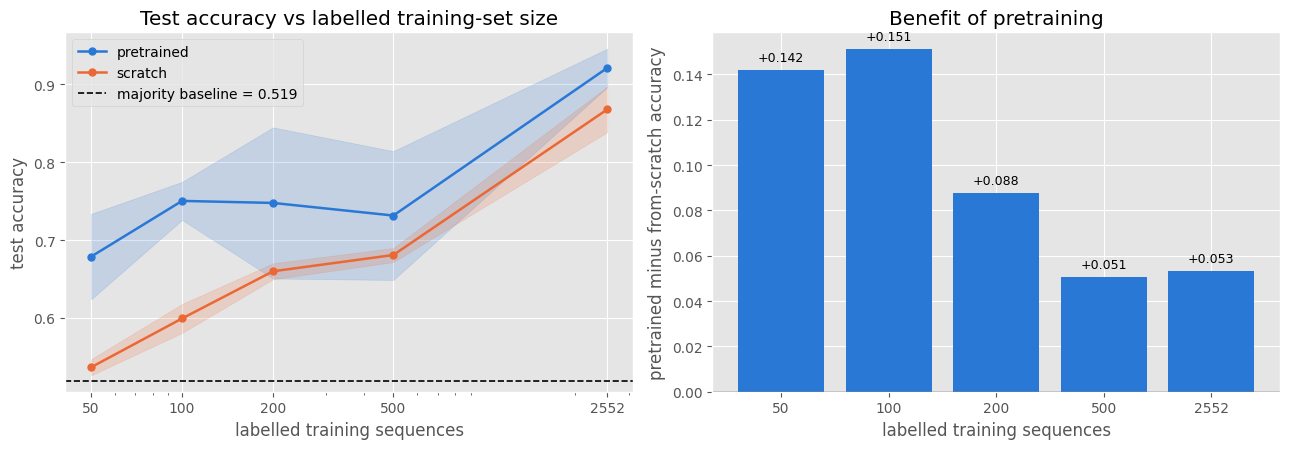

n=   50   pretrained 0.6787   scratch 0.5366   gap +0.1421
n=  100   pretrained 0.7503   scratch 0.5993   gap +0.1510
n=  200   pretrained 0.7476   scratch 0.6599   gap +0.0878
n=  500   pretrained 0.7315   scratch 0.6808   gap +0.0507
n= 2552   pretrained 0.9211   scratch 0.8678   gap +0.0533


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

xs = np.array(SIZES, dtype=float)
for mode, col in [('pretrained', blue), ('scratch', orange)]:
    mu = np.array([results[(n, mode)].mean() for n in SIZES])
    sd = np.array([results[(n, mode)].std() for n in SIZES])
    ax[0].plot(xs, mu, color=col, marker='o', ms=5, lw=1.8, label=mode)
    ax[0].fill_between(xs, mu - sd, mu + sd, color=col, alpha=0.18)
ax[0].axhline(baseline, color='k', ls='--', lw=1.2, label='majority baseline = %.3f' % baseline)
ax[0].set_xscale('log')
ax[0].set_xticks(SIZES)
ax[0].set_xticklabels([str(s) for s in SIZES])
ax[0].set_title('Test accuracy vs labelled training-set size')
ax[0].set_xlabel('labelled training sequences')
ax[0].set_ylabel('test accuracy')
ax[0].legend()

gap = np.array([results[(n, 'pretrained')].mean() - results[(n, 'scratch')].mean() for n in SIZES])
ax[1].bar([str(s) for s in SIZES], gap, color=[blue if v > 0 else orange for v in gap])
ax[1].axhline(0, color='k', lw=1)
for i, v in enumerate(gap):
    ax[1].text(i, v + (0.004 if v >= 0 else -0.012), '%+.3f' % v, ha='center', fontsize=9)
ax[1].set_title('Benefit of pretraining')
ax[1].set_xlabel('labelled training sequences')
ax[1].set_ylabel('pretrained minus from-scratch accuracy')

plt.tight_layout()
plt.show()

for n in SIZES:
    print('n=%5d   pretrained %.4f   scratch %.4f   gap %+.4f'
          % (n, results[(n, 'pretrained')].mean(), results[(n, 'scratch')].mean(),
             results[(n, 'pretrained')].mean() - results[(n, 'scratch')].mean()))

The fine-tuning curves below show the same two conditions over the course of training, at the
smallest labelled set and at the full one. Training loss is on the labelled batches; accuracy is on
the held-out test set.

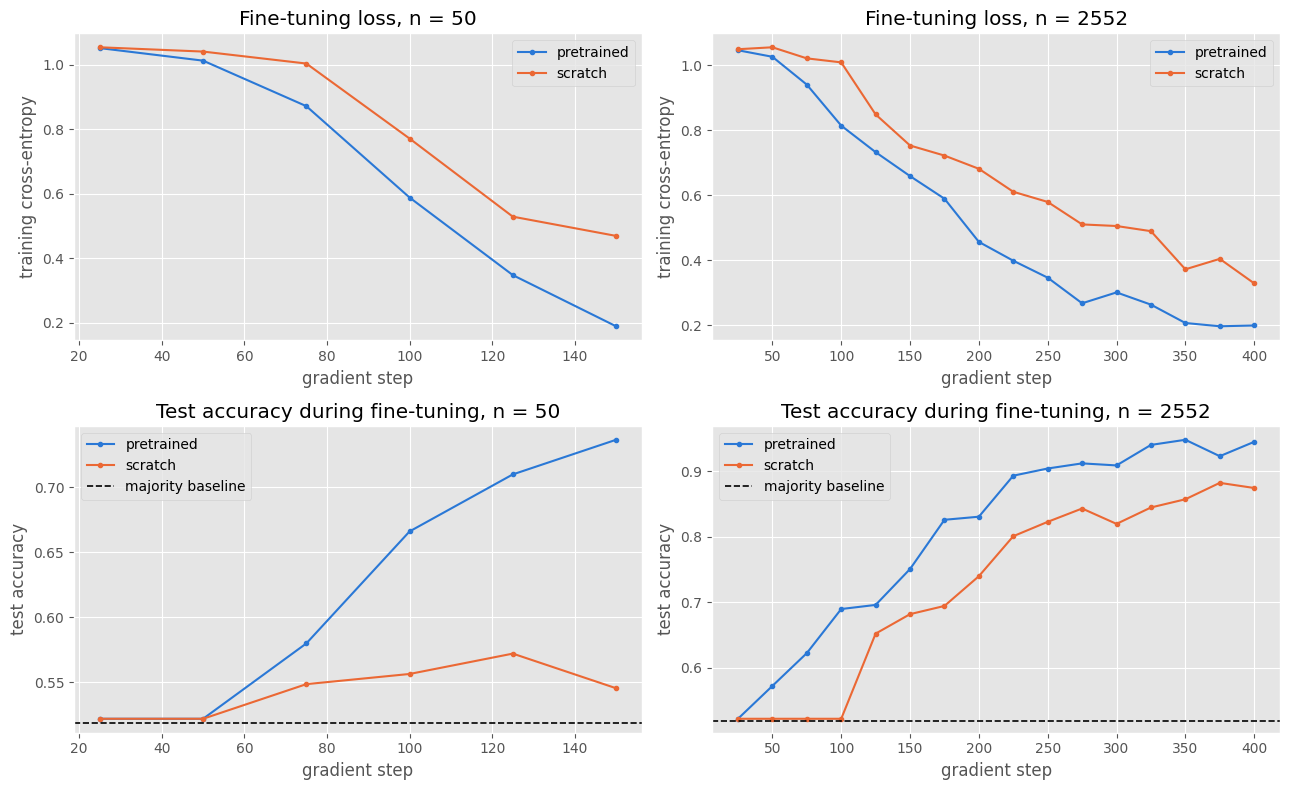

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
show = [SIZES[0], SIZES[-1]]

for c, n in enumerate(show):
    for mode, col in [('pretrained', blue), ('scratch', orange)]:
        cx, cl, ca = curves[(n, mode)]
        ax[0, c].plot(cx, cl, color=col, marker='o', ms=3, label=mode)
        ax[1, c].plot(cx, ca, color=col, marker='o', ms=3, label=mode)
    ax[0, c].set_title('Fine-tuning loss, n = %d' % n)
    ax[0, c].set_xlabel('gradient step')
    ax[0, c].set_ylabel('training cross-entropy')
    ax[0, c].legend()
    ax[1, c].axhline(baseline, color='k', ls='--', lw=1.2, label='majority baseline')
    ax[1, c].set_title('Test accuracy during fine-tuning, n = %d' % n)
    ax[1, c].set_xlabel('gradient step')
    ax[1, c].set_ylabel('test accuracy')
    ax[1, c].legend()

plt.tight_layout()
plt.show()

## What the pretrained encoder attends to

The attention matrix $A^{(l,h)}$ of block $l$ and head $h$ has entry $(i,j)$ equal to the weight
position $i$ places on position $j$. Row 0 is the `[CLS]` row, and it is the one that decides which
positions the classification head ends up reading, because $h_{[CLS]}$ is a weighted sum of value
vectors with those weights.

The heatmaps come from the pretrained encoder, before any label has been seen. If the masked
language model has found the splice-site motif, the `[CLS]` row should not be flat.

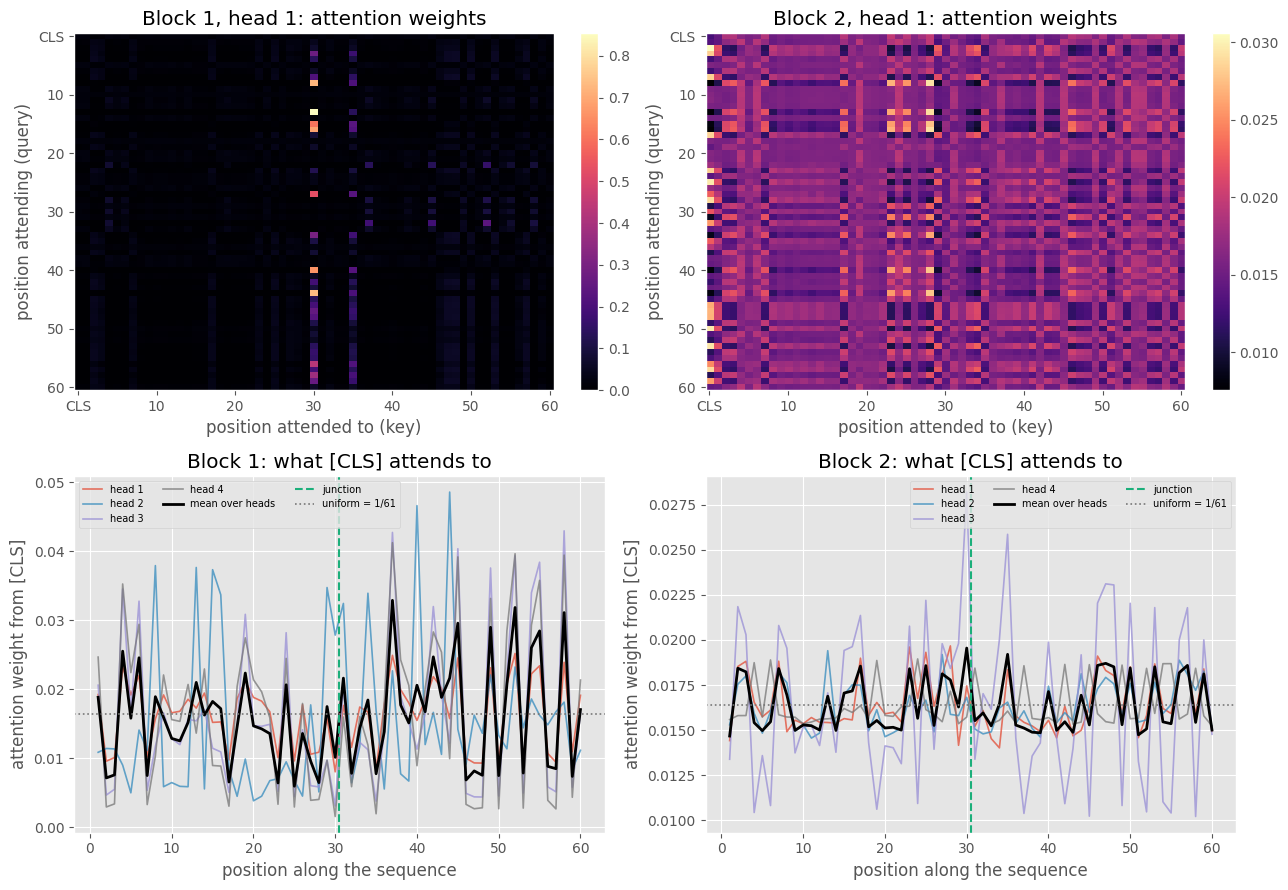

block 2, [CLS] attends most to positions: [17, 25, 30, 35, 46, 47, 53, 57]
attention mass in positions 26-35: 0.172  (uniform would be 0.167)


In [20]:
_, cache_att = encoder_forward(pre_params, ids_test[:8], keep_attn=True)
A0 = cache_att['attn'][0][0]
A1 = cache_att['attn'][1][0]

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
tick = [0, 10, 20, 30, 40, 50, 60]
tlab = ['CLS', '10', '20', '30', '40', '50', '60']

for a, (M, ttl) in zip(ax[0], [(A0[0], 'Block 1, head 1'), (A1[0], 'Block 2, head 1')]):
    im = a.imshow(M, cmap='magma', aspect='auto')
    a.grid(False)
    a.set_title('%s: attention weights' % ttl)
    a.set_xlabel('position attended to (key)')
    a.set_ylabel('position attending (query)')
    a.set_xticks(tick); a.set_xticklabels(tlab)
    a.set_yticks(tick); a.set_yticklabels(tlab)
    fig.colorbar(im, ax=a, fraction=0.046)

xs_pos = np.arange(1, 61)
for a, (M, ttl) in zip(ax[1], [(A0, 'Block 1'), (A1, 'Block 2')]):
    cls_row = M[:, 0, 1:]
    for hh in range(n_heads):
        a.plot(xs_pos, cls_row[hh], lw=1.2, alpha=0.75, label='head %d' % (hh + 1))
    a.plot(xs_pos, cls_row.mean(0), color='k', lw=2.0, label='mean over heads')
    a.axvline(30.5, color=green, ls='--', lw=1.5, label='junction')
    a.axhline(1.0 / 61, color='#777777', ls=':', lw=1.2, label='uniform = 1/61')
    a.set_title('%s: what [CLS] attends to' % ttl)
    a.set_xlabel('position along the sequence')
    a.set_ylabel('attention weight from [CLS]')
    a.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.show()

cls_mean = A1[:, 0, 1:].mean(0)
top = np.argsort(cls_mean)[::-1][:8] + 1
print('block 2, [CLS] attends most to positions:', sorted(top.tolist()))
print('attention mass in positions 26-35: %.3f  (uniform would be %.3f)'
      % (cls_mean[25:35].sum() / cls_mean.sum(), 10 / 60))

## Which positions are predictable

The MLM accuracy reported during pretraining is an average over randomly chosen positions. Breaking
it down by position asks a sharper question: given the other 59 bases, how well can the model
recover the base at position $j$?

The cell below masks one position at a time - position $j$ replaced by `[MASK]` in every one of 256
held-out sequences, with nothing else altered - and measures how often the true base is recovered.
Background positions should sit near the frequency of the most common base, because there is little
to condition on. Positions inside the splice-site motif should be much higher, since a donor site
begins `GT` and an acceptor site ends `AG` almost without exception, and those bases are strongly
determined by their neighbours. A bump localised at the junction is evidence that pretraining picked
up real biology rather than the marginal base frequencies.

probed 20/60 positions [10s]


probed 40/60 positions [20s]


probed 60/60 positions [31s]


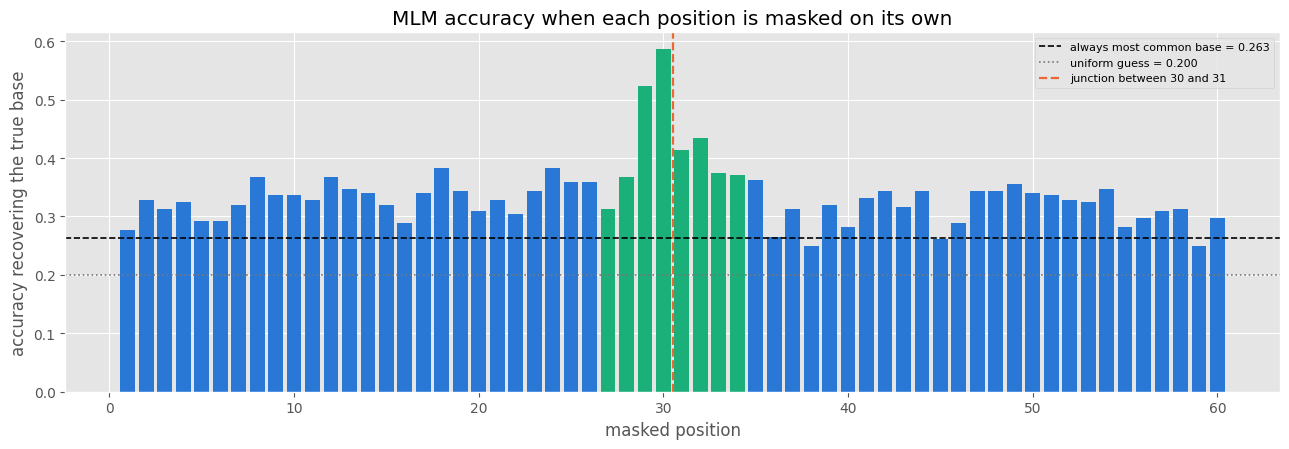

mean accuracy, junction window 27-34: 0.4229
mean accuracy, background positions : 0.3227
best position: 30 at 0.5859


In [21]:
probe = ids_test[:256]
per_pos_acc = np.zeros(60)

t_probe = time.time()
for j in range(1, 61):
    inp = probe.copy()
    inp[:, j] = MASK_ID
    h, _ = encoder_forward(pre_params, inp)
    hs = h[:, j, :]
    logits = lin_forward(gelu(lin_forward(hs, pre_params['mlm_W1'], pre_params['mlm_b1'])),
                         pre_params['mlm_W2'], pre_params['mlm_b2'])
    per_pos_acc[j - 1] = (logits.argmax(1) == probe[:, j]).mean()
    if j % 20 == 0:
        print('probed %d/60 positions [%.0fs]' % (j, time.time() - t_probe), flush=True)

fig, ax = plt.subplots(figsize=(13, 4.6))
xs_pos = np.arange(1, 61)
ax.bar(xs_pos, per_pos_acc, color=[green if 27 <= q <= 34 else blue for q in xs_pos], width=0.8)
ax.axhline(majority_base, color='k', ls='--', lw=1.2, label='always most common base = %.3f' % majority_base)
ax.axhline(uniform_chance, color='#777777', ls=':', lw=1.2, label='uniform guess = %.3f' % uniform_chance)
ax.axvline(30.5, color=orange, ls='--', lw=1.6, label='junction between 30 and 31')
ax.set_title('MLM accuracy when each position is masked on its own')
ax.set_xlabel('masked position')
ax.set_ylabel('accuracy recovering the true base')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

motif = per_pos_acc[26:34]
bg = np.concatenate([per_pos_acc[:20], per_pos_acc[40:]])
print('mean accuracy, junction window 27-34: %.4f' % motif.mean())
print('mean accuracy, background positions : %.4f' % bg.mean())
print('best position: %d at %.4f' % (int(per_pos_acc.argmax()) + 1, per_pos_acc.max()))

## Confusion matrix

The matrix below is the fine-tuned pretrained model at the full labelled training-set size, on the
638 held-out sequences. The diagonal is correct predictions. `EI` and `IE` are the two junction
types and `N` is everything else, so confusions between `EI` and `IE` mean the model found a
junction but read its direction wrongly, while confusions with `N` mean it disagreed about whether
there is a junction at all.

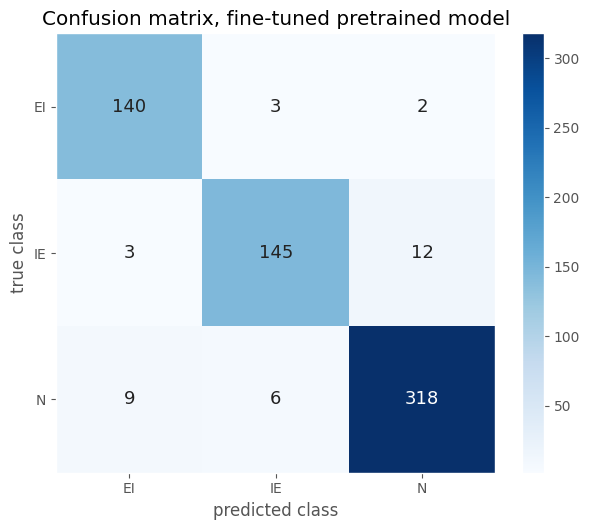

test accuracy 0.9451  against baseline 0.5188
  EI  recall 0.966   precision 0.921
  IE  recall 0.906   precision 0.942
  N   recall 0.955   precision 0.958


In [22]:
h, _ = encoder_forward(final_model, ids_test)
pred = lin_forward(h[:, 0, :], final_model['cls_W'], final_model['cls_b']).argmax(1)

cm = np.zeros((3, 3), dtype=int)
for t, q in zip(y_test, pred):
    cm[t, q] += 1

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(cm, cmap='Blues')
ax.grid(False)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=13,
                color='white' if cm[i, j] > cm.max() * 0.55 else '#222222')
ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('predicted class')
ax.set_ylabel('true class')
ax.set_title('Confusion matrix, fine-tuned pretrained model')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print('test accuracy %.4f  against baseline %.4f' % ((pred == y_test).mean(), baseline))
for i, c in enumerate(CLASSES):
    print('  %-3s recall %.3f   precision %.3f'
          % (c, cm[i, i] / cm[i].sum(), cm[i, i] / max(1, cm[:, i].sum())))

## What the numbers say

In [23]:
print('=' * 68)
print('BERT from scratch - splice-junction sequences')
print('=' * 68)
print('majority-class baseline                  %.4f' % baseline)
print('parameters                               %d (%d in the encoder)' % (n_params, n_encoder))
print()
print('Stage 1, masked language modelling on %d unlabelled sequences' % len(ids_train))
print('  masked-token accuracy                  %.4f' % mlm_acc_hist[-1])
print('  uniform guess / most common base       %.4f / %.4f' % (uniform_chance, majority_base))
print('  junction window vs background          %.4f / %.4f' % (motif.mean(), bg.mean()))
print()
print('Stage 2, fine-tuning')
print('  %-8s %-22s %-22s %s' % ('n', 'pretrained', 'from scratch', 'gap'))
for n in SIZES:
    a, b = results[(n, 'pretrained')], results[(n, 'scratch')]
    print('  %-8d %.4f +- %.4f       %.4f +- %.4f       %+.4f'
          % (n, a.mean(), a.std(), b.mean(), b.std(), a.mean() - b.mean()))
print()
print('total notebook runtime: %.1f minutes' % ((time.time() - notebook_start) / 60))

BERT from scratch - splice-junction sequences
majority-class baseline                  0.5188
parameters                               20779 (19360 in the encoder)

Stage 1, masked language modelling on 2552 unlabelled sequences
  masked-token accuracy                  0.4019
  uniform guess / most common base       0.2000 / 0.2628
  junction window vs background          0.4229 / 0.3227

Stage 2, fine-tuning
  n        pretrained             from scratch           gap
  50       0.6787 +- 0.0549       0.5366 +- 0.0104       +0.1421
  100      0.7503 +- 0.0244       0.5993 +- 0.0186       +0.1510
  200      0.7476 +- 0.0970       0.6599 +- 0.0102       +0.0878
  500      0.7315 +- 0.0827       0.6808 +- 0.0090       +0.0507
  2552     0.9211 +- 0.0247       0.8678 +- 0.0292       +0.0533

total notebook runtime: 21.9 minutes


### Reading the result honestly

The sweep is the whole point of the notebook and it should be read without wishful thinking.

At the full labelled training-set size there are 2552 labelled sequences for a model with roughly
twenty thousand parameters. There is no scarcity of labels for pretraining to compensate for, and
whatever an unsupervised pass extracts from those same 2552 sequences, supervised training on them
can also extract. **A gap at the right-hand end of the curve is not expected, and if the two
conditions land on top of each other there, that is the correct result rather than a failure.** The
printed table above gives the actual numbers.

The place where the argument can be tested is the left-hand end. At 50 labelled sequences a randomly
initialised encoder has to discover, from 50 examples, both that position matters and where the
motif is; a pretrained encoder has already been told where the motif is by a task that needed no
labels at all, and only has to learn to map that representation onto three class names. If
pretraining is worth anything on this data, it is worth it there.

Three caveats bound how much weight the numbers carry:

- The pretraining corpus is the training split itself, 2552 sequences of 60 bases. Real BERT
  pretrains on billions of tokens. There is a limit to how much structure can be extracted from a
  corpus this small, and 12 epochs of MLM is a short schedule.
- The model has 2 blocks and $d = 32$. Most of what makes pretraining transformative at scale -
  capacity to store a lot of structure that a small labelled set could never supply - is absent by
  construction.
- Three seeds at $n = 50$ still leaves a wide standard deviation. Differences smaller than the bands
  drawn on the figure should not be read as real.

What does hold up independently of the sweep is the per-position probe. The masked language model
was never shown a label, and the positions it can predict best are concentrated at the junction, in
the same window where the base composition plot at the top of the notebook shows the motif. That is
a real signal recovered by an unsupervised objective, and it is the mechanism the fine-tuning stage
is supposed to be exploiting.